### 生成数据(传统方法)

In [9]:
import csv
import random
import math

# 用户输入
number = int(input("请输入试验次数: "))
money = float(input("请输入总金额: "))
people = int(input("请输入人数: "))

# 检查人数是否过多
if people > money * 100:
    print("people is too many")
else:
    # 创建CSV文件
    with open('envelopes.csv', 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        
        # 写入表头
        header = ['Trial'] + [f'Person{p}' for p in range(1, people + 1)]
        writer.writerow(header)
        
        # 存储所有试验结果
        all_results = []
        
        # 执行number次试验
        for j in range(number):
            envelopes = []
            remaining_money = money
            
            for i in range(people):
                # 计算剩余人数
                remaining_people = people - i
                
                # 计算剩余钱的平均值
                avg_money = remaining_money / remaining_people
                
                # 计算最大可分配金额
                max_possible_avg = min(avg_money * 2, 
                                     remaining_money - (remaining_people - 1) * 0.01)
                min_amount = 0.01
                max_amount = max(max_possible_avg, min_amount)
                
                # 如果是最后一个人，给他所有剩余的钱
                if i == people - 1:
                    money_get = round(remaining_money, 2)
                else:
                    # 生成随机金额
                    money_get = random.uniform(min_amount, max_amount)
                    money_get = round(money_get, 2)
                
                envelopes.append(money_get)
                remaining_money -= money_get
                # 由于浮点数精度问题，确保remaining_money保持两位小数
                remaining_money = round(remaining_money, 2)
            
            # 写入当前试验结果
            row = [j + 1] + envelopes
            writer.writerow(row)
            all_results.append(envelopes)
        
        # 写入总计行（每个人的总金额）
        total_row = ['Total']
        for p in range(people):
            person_total = sum(all_results[j][p] for j in range(number))
            total_row.append(round(person_total, 2))
        writer.writerow(total_row)
        
    
    print("CSV文件已生成: envelopes.csv")

CSV文件已生成: envelopes.csv


### 导入数据
计算mean,variance,std,median,min，max

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取CSV数据
path = "envelopes.csv"
raw = pd.read_csv(path)

# 2. 按行读取数据
data = raw.iloc[1:number].reset_index(drop=True)

# 3. 位次列
pos_cols = data.columns[1:people+1]

# 4. 转成长表
long_df = data[pos_cols].melt(
    var_name="position",
    value_name="amount"
).dropna()

# 提取位次编号
long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) 

# 5. 统计信息
stats = long_df.groupby("pos_id")["amount"].agg(
    mean="mean",
    variance="var",
    std="std",
    median="median",
    min="min",
    max="max"
)

print(stats)

             mean   variance       std  median   min    max
pos_id                                                     
1        9.980326  33.272291  5.768214   10.04  0.01  19.99
2       10.019776  33.869443  5.819746    9.99  0.02  22.12
3       10.005319  34.587466  5.881111    9.83  0.01  23.95
4       10.012885  35.343337  5.945026    9.85  0.01  26.20
5        9.959663  36.158884  6.013226    9.70  0.01  28.63
6       10.026341  38.682633  6.219536    9.64  0.01  33.73
7       10.018022  41.238202  6.421698    9.39  0.01  36.89
8        9.940223  46.532407  6.821467    9.14  0.01  40.48
9       10.108307  59.651223  7.723420    8.58  0.01  61.99
10       9.929139  58.651442  7.658423    8.26  0.01  58.26


Diffusion Model生成数据：

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取CSV数据
path = "generated_samples.csv"
raw = pd.read_csv(path)

# 2. 直接使用所有行，不需要额外的number参数
data = raw.copy()

# 3. 确定人数（列数）
people = data.shape[1]  # 列数代表人数
print(f"人数：{people}")

# 4. 为数据添加列名
pos_cols = [f"position_{i+1}" for i in range(people)]
data.columns = pos_cols

# 4. 转成长表
long_df = data[pos_cols].melt(
    var_name="position",
    value_name="amount"
).dropna()

# 提取位次编号
long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) 

# 5. 统计信息
stats = long_df.groupby("pos_id")["amount"].agg(
    mean="mean",
    variance="var",
    std="std",
    median="median",
    min="min",
    max="max"
)

print(stats)

人数：10
             mean   variance       std  median   min    max
pos_id                                                     
1       10.223103  31.462740  5.609166   10.17  0.02  24.07
2        9.385636  32.608584  5.710393    9.29  0.01  25.30
3       10.392603  35.169679  5.930403   10.17  0.05  26.98
4        9.934324  37.126048  6.093115    9.42  0.01  27.26
5       10.300140  35.176372  5.930967   10.13  0.09  29.25
6        9.607497  35.181071  5.931363    9.52  0.00  31.62
7        9.491081  39.000803  6.245062    8.72  0.00  30.44
8        9.284905  44.406287  6.663804    8.24  0.03  35.16
9       10.841431  62.512003  7.906453    9.26  0.01  46.26
10      10.539279  50.840832  7.130276    9.23  0.02  37.77


#### 箱线图和散点图

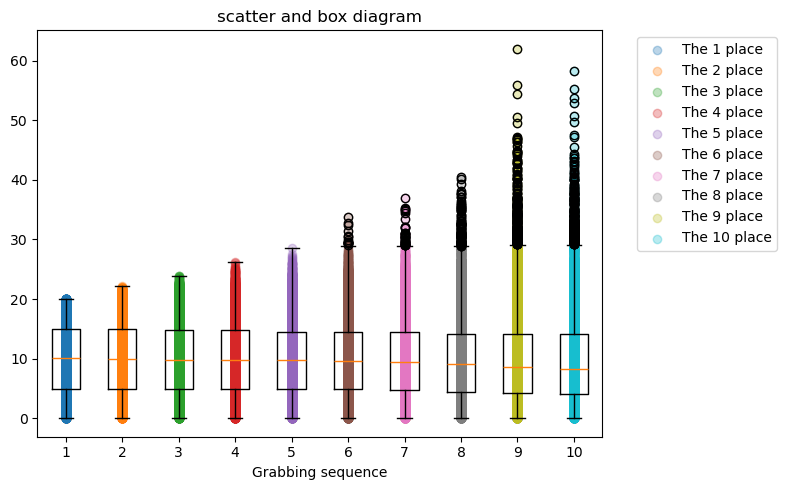

In [12]:
# 准备箱线图数据
box_data = [
    long_df[long_df["pos_id"] == pos]["amount"].values
    for pos in sorted(long_df["pos_id"].unique())
]
# 6. 散点图（不同位次不同颜色）
plt.figure(figsize=(8, 5))
plt.boxplot(box_data, showfliers=True)

for pos in sorted(long_df["pos_id"].unique()):
    y = long_df[long_df["pos_id"] == pos]["amount"]
    x = np.full(len(y), pos)
    plt.scatter(x, y, alpha=0.3, label=f"The {pos} place")

plt.xlabel("Grabbing sequence")
plt.ylabel("")
plt.title("scatter and box diagram")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 画直方图（看分布形态）


蓝色为Diffusin Model生成数据的直方图，可以发现position_1不符合理论上的均匀分布，但当数据量足够大时，还是比较相似的。
这组数据 数据规模=10000，红包总额=100，人数=10

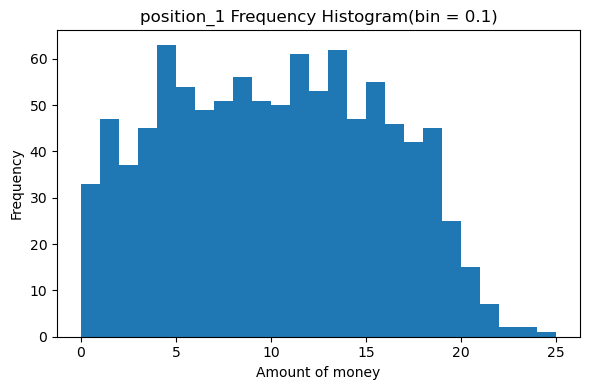

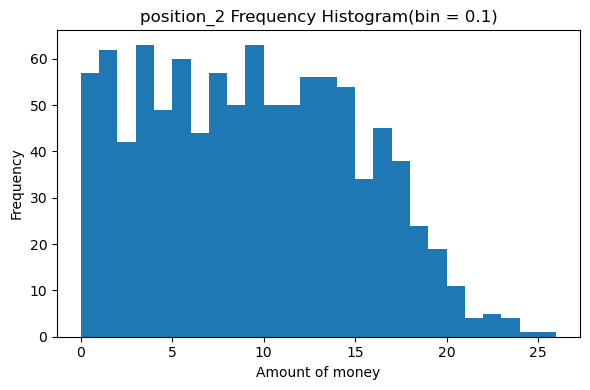

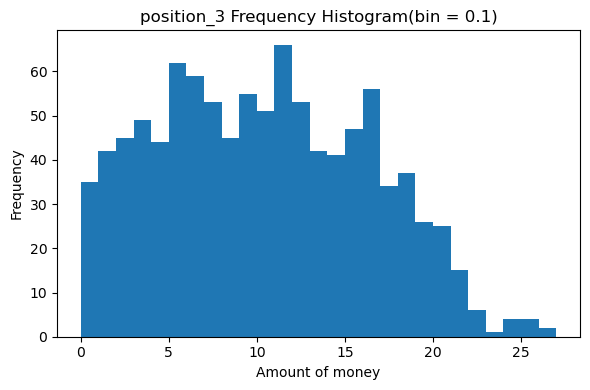

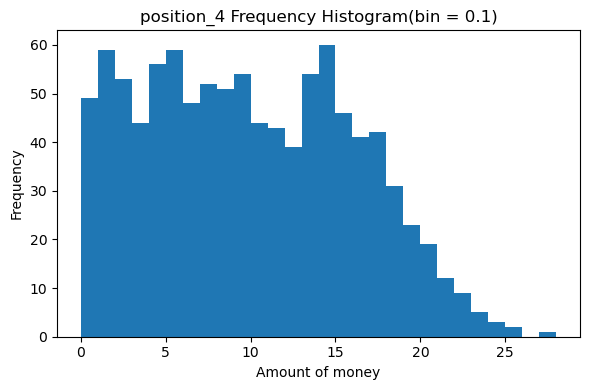

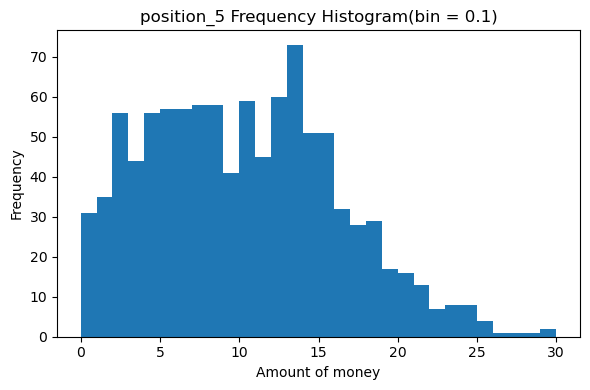

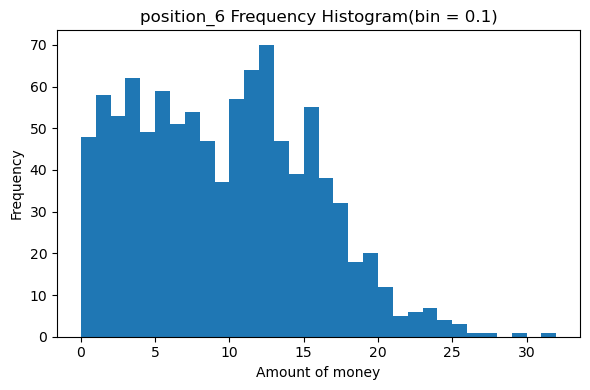

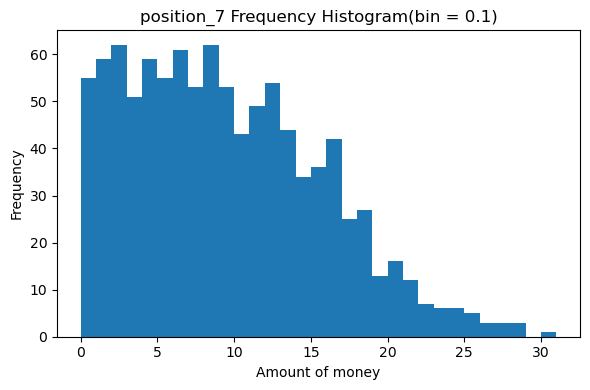

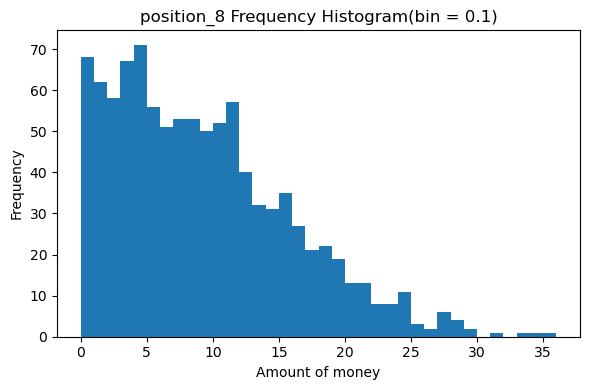

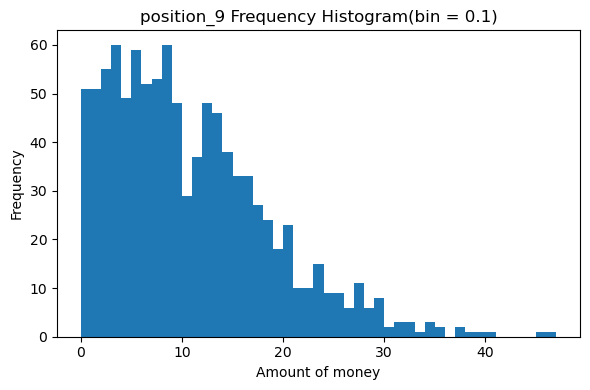

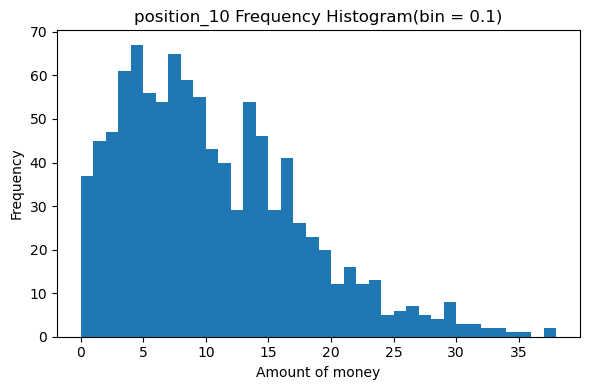

                  bin_left  bin_right  count
position   index                            
position_1 0           0.0        1.0     33
           1           1.0        2.0     47
           2           2.0        3.0     37
           3           3.0        4.0     45
           4           4.0        5.0     63


In [56]:
# 4. 直方图区间宽度
bin_width = 1

# 用于保存所有位次的频数统计结果
hist_tables = {}

for col in pos_cols:
    values = data[col].dropna().values
    
    # 构造 bins
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)
    
    # 计算直方图频数
    counts, edges = np.histogram(values, bins=bins)
    
    # 记录频数表
    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df
    
    # 绘制直方图
    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=bins)
    plt.xlabel("Amount of money")
    plt.ylabel("Frequency")
    plt.title(f"{col} Frequency Histogram(bin = 0.1)")
    plt.tight_layout()
    plt.show()

# 5. 合并所有位次的频数统计（方便统一分析）
all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())

这是按照分布生成数据的直方图，可以与前面的直方图进行对比。最后几位的直方图已经显示出明显的长尾效应，看上去更像是指数分布，理论上也确实如此。

Person1


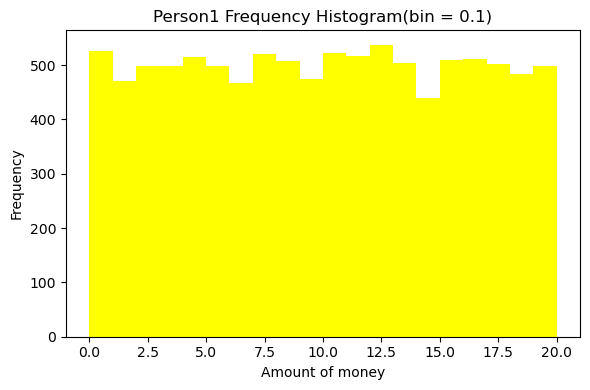

Person2


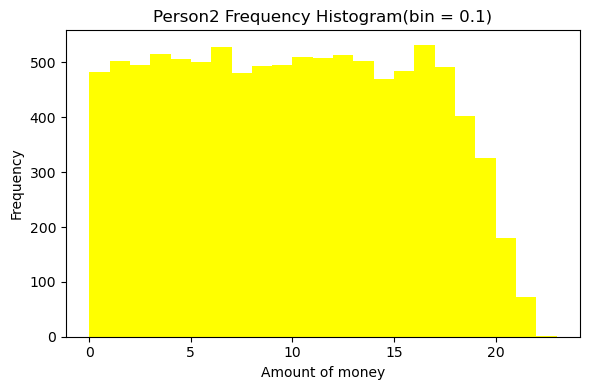

Person3


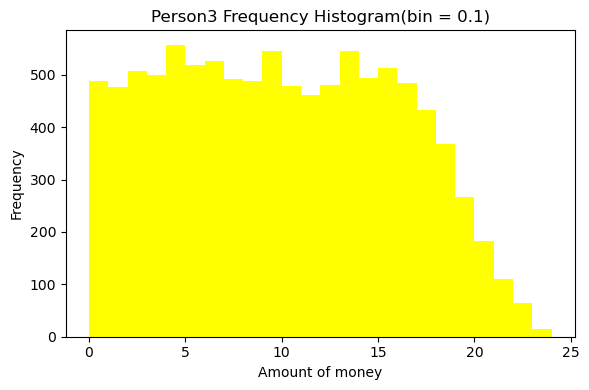

Person4


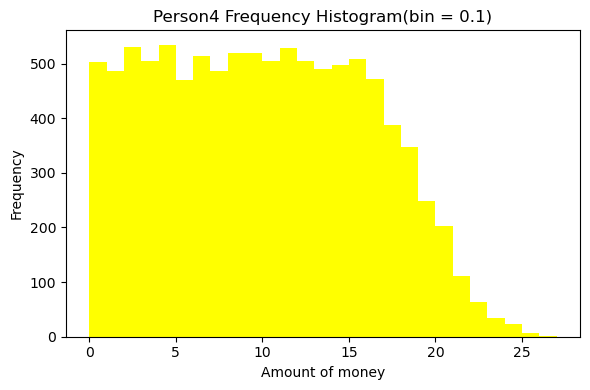

Person5


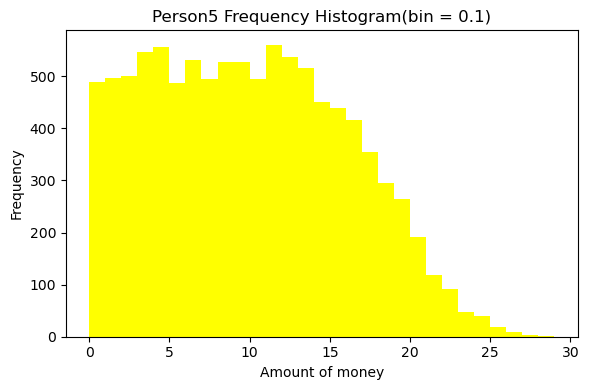

Person6


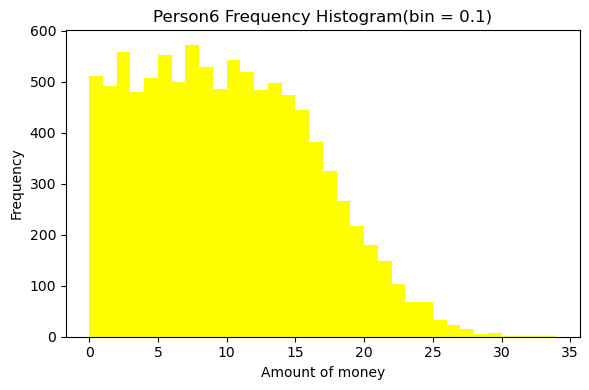

Person7


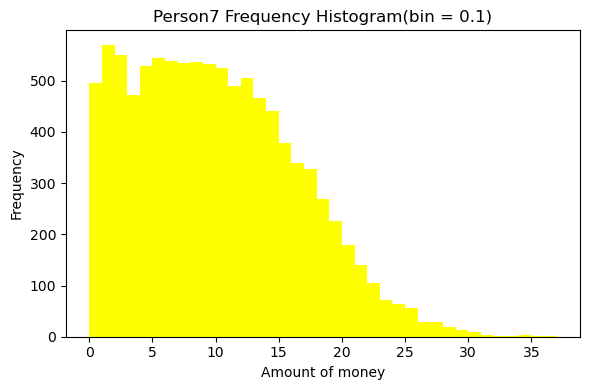

Person8


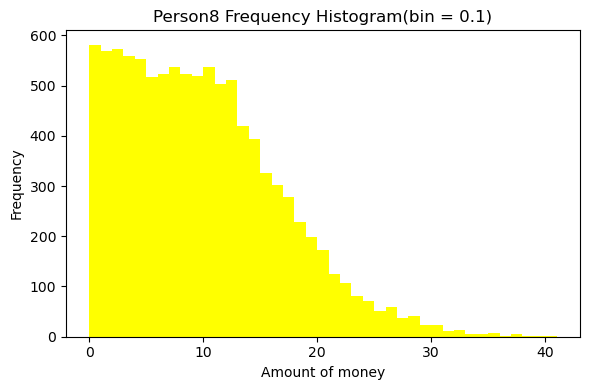

Person9


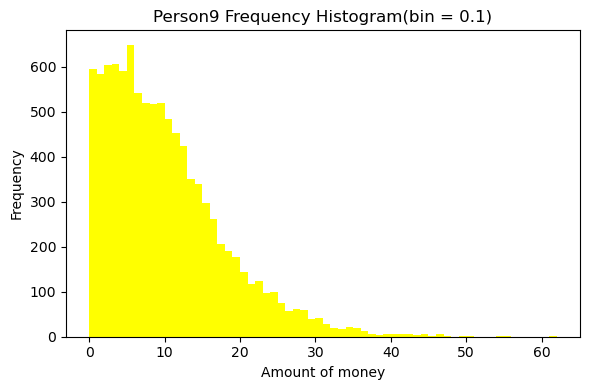

Person10


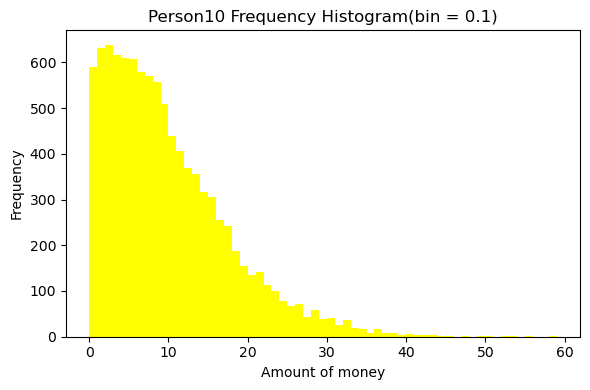

                bin_left  bin_right  count
position index                            
Person1  0           0.0        1.0    525
         1           1.0        2.0    471
         2           2.0        3.0    498
         3           3.0        4.0    499
         4           4.0        5.0    515


In [38]:
# 4. 直方图区间宽度
bin_width = 1

# 用于保存所有位次的频数统计结果
hist_tables = {}

for col in pos_cols:
    print(col)
    values = data[col].dropna().values
    
    # 构造 bins
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)
    
    # 计算直方图频数
    counts, edges = np.histogram(values, bins=bins)
    
    # 记录频数表
    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df
    
    # 绘制直方图
    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=bins)
    plt.xlabel("Amount of money")
    plt.ylabel("Frequency")
    plt.title(f"{col} Frequency Histogram(bin = 0.1)")
    plt.hist(values, bins=bins, color='yellow')
    plt.tight_layout()
    plt.show()

# 5. 合并所有位次的频数统计（方便统一分析）
all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())

我们再来看看人数较多时的情况(P=1000)，并对最后几位的分布图与指数分布进行对照。

<>:59: SyntaxWarning: invalid escape sequence '\l'
<>:59: SyntaxWarning: invalid escape sequence '\l'
C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_22868\1106813147.py:59: SyntaxWarning: invalid escape sequence '\l'
  label=f'Exp Dist ($\lambda$={lam:.4f})')


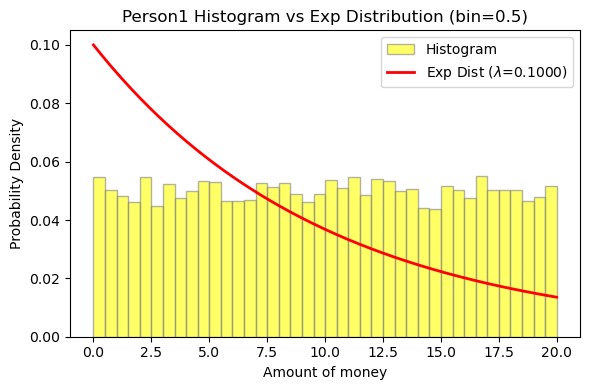

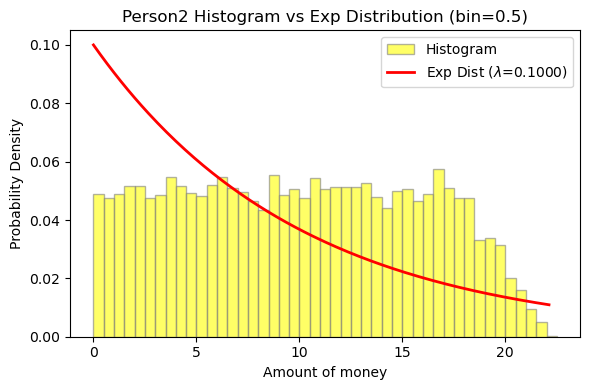

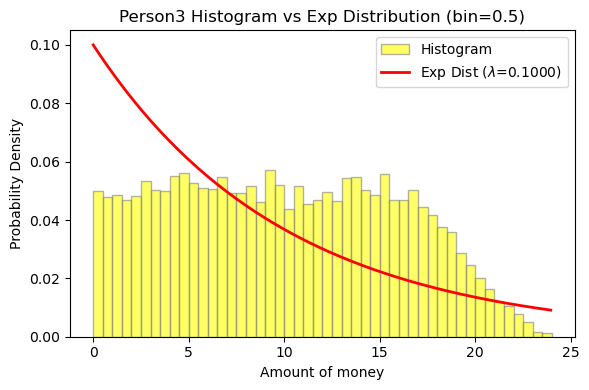

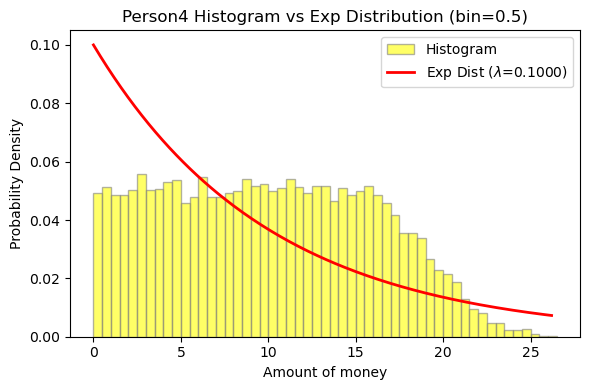

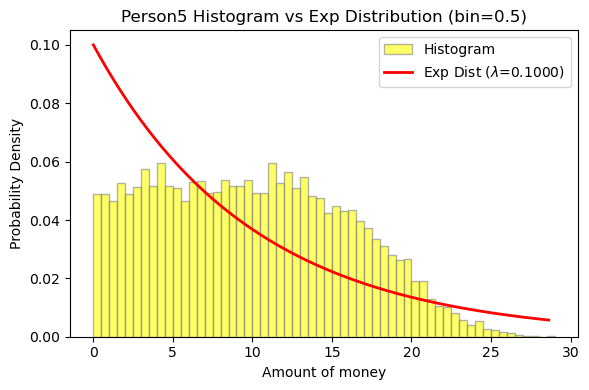

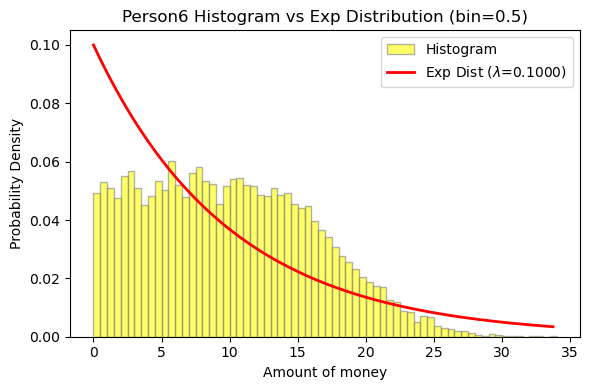

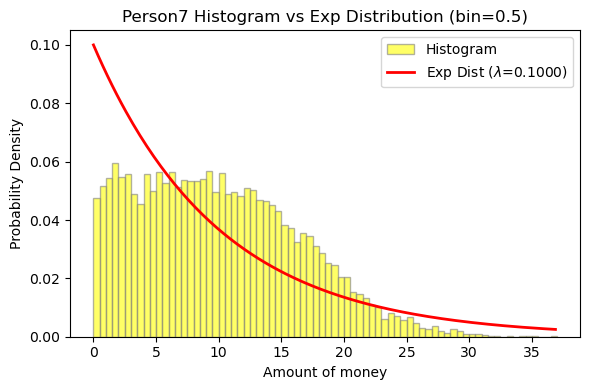

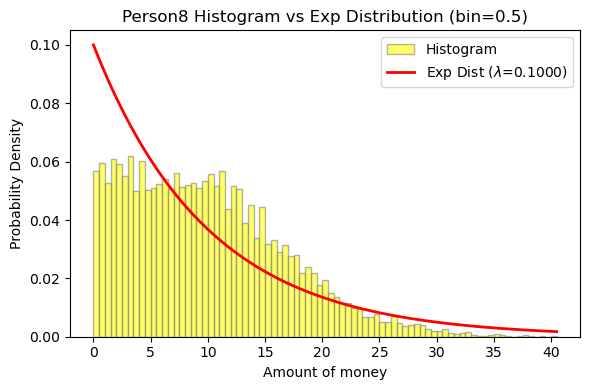

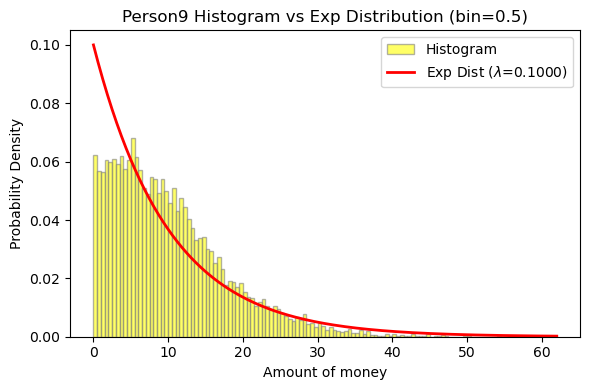

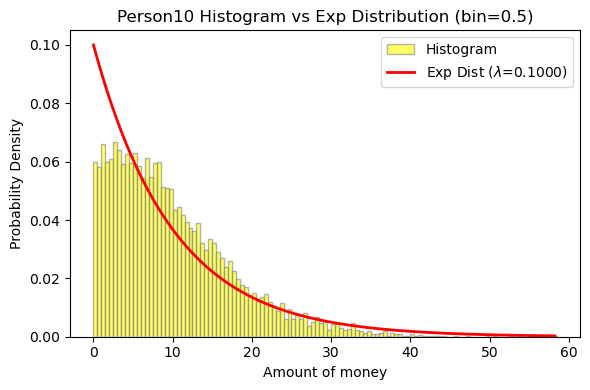

                bin_left  bin_right  count
position index                            
Person1  0           0.0        0.5    273
         1           0.5        1.0    252
         2           1.0        1.5    241
         3           1.5        2.0    230
         4           2.0        2.5    274


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 假设 bin_width 0.5
bin_width = 0.5

# 用于保存所有位次的频数统计结果
hist_tables = {}

# 使用 enumerate 获取索引 i，用于判断是否是第 10 列
for i, col in enumerate(pos_cols):
    values = data[col].dropna().values
    
    # 构造 bins
    if len(values) == 0: continue # 防止空数据报错
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)
    
    # --- 1. 计算直方图频数 (用于保存表格，保持原有逻辑) ---
    counts, edges = np.histogram(values, bins=bins)
    
    # 记录频数表
    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df
    
    # --- 2. 绘制直方图与指数分布对比 (每10列取样一次) ---
    #if i % 10 == 0 and i >=900:
    if True:
        plt.figure(figsize=(6, 4))
        
        # A. 画直方图
        # 注意：这里必须设置 density=True，将频数转为概率密度，否则高度无法与概率曲线对比
        plt.hist(values, bins=bins, density=True, color='yellow', 
                 edgecolor='grey', alpha=0.6, label='Histogram')
        
        # B. 画指数分布概率密度函数 (PDF)
        # 估计 lambda 参数：指数分布的 lambda 通常估计为 1 / 均值
        # 如果你有固定的 lambda 值，可以直接赋值，例如: lam = 0.5
        lam = 0.1
        
        # 生成平滑的 x 轴坐标点
        x_curve = np.linspace(0, max_val, 200)
        # 计算对应的 y 值：f(x) = lambda * exp(-lambda * x)
        y_curve = lam * np.exp(-lam * x_curve)
        
        plt.plot(x_curve, y_curve, color='red', linewidth=2, 
                 label=f'Exp Dist ($\lambda$={lam:.4f})')
        
        # C. 图表设置
        plt.xlabel("Amount of money")
        plt.ylabel("Probability Density") # Y轴现在是密度，不再是简单的频数
        plt.title(f"{col} Histogram vs Exp Distribution (bin={bin_width})")
        plt.legend() # 显示图例
        plt.tight_layout()
        plt.show()

# 5. 合并所有位次的频数统计（保持不变）
all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())

K-S检验验证第一个人抢到的金融是否是均匀分布。

In [44]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 提取第一个人的数据
first_place_data = data['Person1'].dropna().values
print(first_place_data)

# 2. 执行 K-S 检验
# args=(a, range) -> loc=a, scale=b-a
# 假设我们要检验数据是否服从 U(0, money/people)
statistic, p_value = stats.kstest(first_place_data, 'uniform', args=(0, 2*money/people))

print(f"K-S 统计量: {statistic:.4f}")
print(f"P值: {p_value:.4f}")

# 3. 结果解读
alpha = 0.05
if p_value < alpha:
    print("拒绝原假设：数据不服从 Uniform(0, 2*m/n)")
else:
    print("接受原假设：数据可能服从 Uniform(0, 2*m/n)")

[11.61  8.03  9.2  ... 13.04  6.72 19.5 ]
K-S 统计量: 0.0070
P值: 0.7138
接受原假设：数据可能服从 Uniform(0, 2*m/n)


K-S检验验证最后一个人抢到的金额是否符合指数分布

对于指数分布，除了看 $P$ 值，Q-Q 图 是最专业的辅助工具。原理： 将样本的各个分位数与指数分布的理论分位数画在散点图上。判断标准： 如果数据服从指数分布，散点应该几乎在一条 45 度的斜线上。

[15.18  3.86  4.56 ...  6.9   3.32 11.27]
K-S 统计量: 0.9370
P值: 0.0000
拒绝原假设：数据不服从 Uniform(0, n/m)


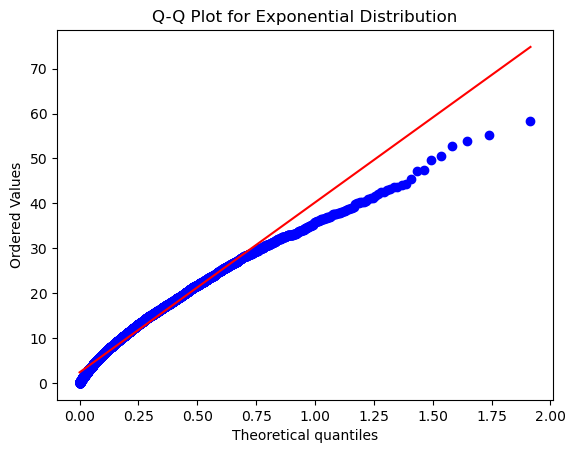

In [48]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 提取最后一个人的数据
last_place_data = data['Person10'].dropna().values
print(first_place_data)

# 2. 执行 K-S 检验
# 检验数据是否服从指数分布
loc_est, scale_est = 0, 2*people/money
statistic, p_value = stats.kstest(first_place_data, 'expon', args=(loc_est, scale_est))

print(f"K-S 统计量: {statistic:.4f}")
print(f"P值: {p_value:.4f}")

# 3. 结果解读
alpha = 0.05
if p_value < alpha:
    print("拒绝原假设：数据不服从 Uniform(0, n/m)")
else:
    print("接受原假设：数据可能服从 Uniform(0, n/m)")

stats.probplot(last_place_data, dist="expon", sparams=(loc_est, scale_est), plot=plt)
plt.title("Q-Q Plot for Exponential Distribution")
plt.show()